# Site Figure 

In [1]:
# Loading in necessary packages 

from polartoolkit import fetch, maps, regions, utils

In [2]:
# Defining layer names and grids from Polar Toolkit 
layer_names = [
    # topographies
    "surface",
    "icebase",
    "bed",
    # thicknesses
    "ice_thickness",
    "water_thickness",
    # uncertainties
    "bed_uncertainty",
    "ice_thickness_uncertainty",
    # others
    "mask",
]

grids = []
for name in layer_names:
    data = fetch.bedmap3(
        layer=name,
        # available options
        # reference ("eigen-gl04c" or "ellipsoid")
        # region,
        # spacing,
        # registration ("g" for gridline or "p" for pixel),
        # fill_nans (True or False),
    )
    grids.append(data)
    print(f"Info for {name}")
    _ = utils.get_grid_info(data, print_info=True)
    print("##########")

Info for surface
grid spacing: 500.0 m
grid region: (-3333000.0, 3333000.0, -3333000.0, 3333000.0)
grid zmin: 1.0
grid zmax: 4711.34765625
grid registration: g
##########
Info for icebase
grid spacing: 500.0 m
grid region: (-3333000.0, 3333000.0, -3333000.0, 3333000.0)
grid zmin: -2973.46875
grid zmax: 4634.91015625
grid registration: g
##########
Info for bed
grid spacing: 500.0 m
grid region: (-3333000.0, 3333000.0, -3333000.0, 3333000.0)
grid zmin: -7409.0
grid zmax: 4634.91015625
grid registration: g
##########
Info for ice_thickness
grid spacing: 500.0 m
grid region: (-3333000.0, 3333000.0, -3333000.0, 3333000.0)
grid zmin: 0.0
grid zmax: 4751.06640625
grid registration: g
##########
Info for water_thickness
grid spacing: 500.0 m
grid region: (-3333000.0, 3333000.0, -3333000.0, 3333000.0)
grid zmin: 0.0
grid zmax: 2807.65893555
grid registration: g
##########
Info for bed_uncertainty
grid spacing: 500.0 m
grid region: (-3333000.0, 3333000.0, -3333000.0, 3333000.0)
grid zmin: 7.0
g

# Antarctic Topographic Map with Site Locations

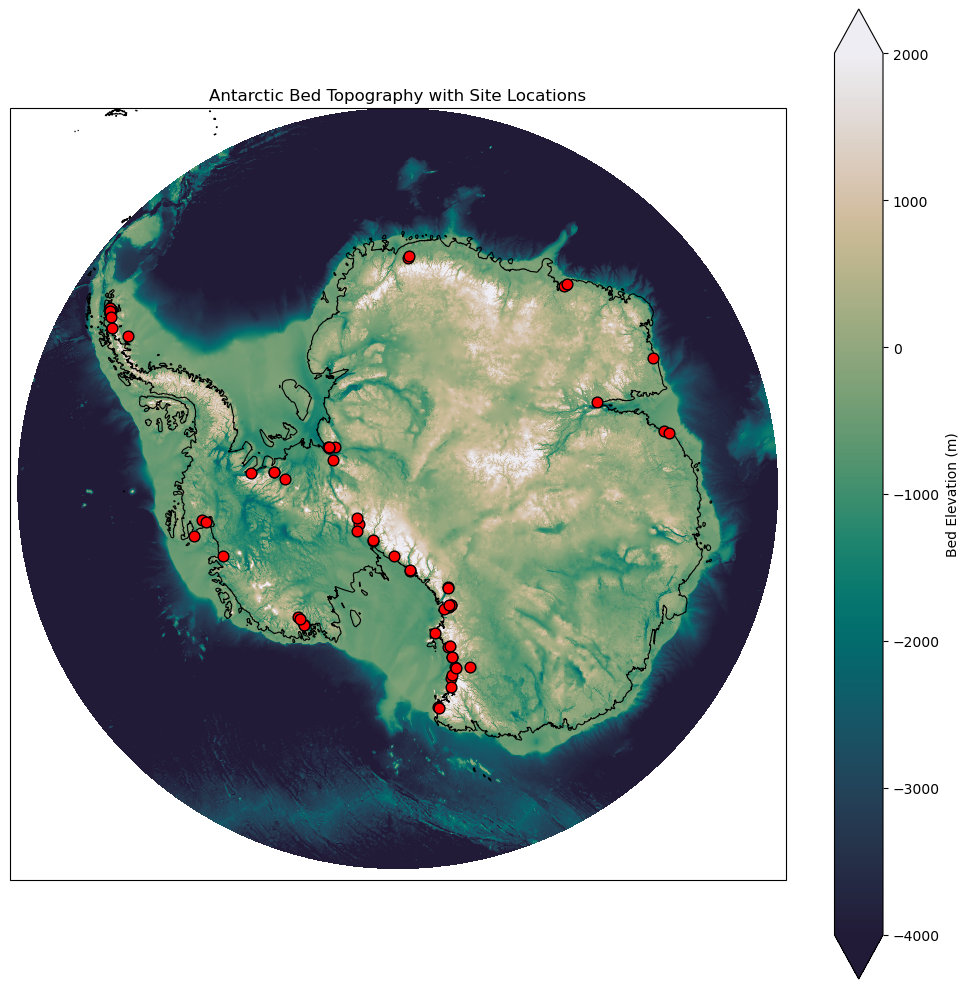

<Figure size 640x480 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import cmocean

# Load exfiltration sites
exfiltration_df = pd.read_csv("paleoexfiltrationperm13mean.csv")
unique_sites = exfiltration_df[['Site', 'Latitude', 'Longitude']].drop_duplicates()

# Load bed topography
bed = fetch.bedmap3(layer="bed")

# Create map
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())

# Plot bed topography with custom colorbar limits
bed.plot(
    ax=ax,
    transform=ccrs.SouthPolarStereo(),
    cmap=cmocean.cm.rain_r,
    vmin=-4000,
    vmax=2000,
    cbar_kwargs={'label': 'Bed Elevation (m)'}
)


# Add coastlines and extent
ax.coastlines(resolution='10m', linewidth=0.8)
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

# Plot site markers
for _, row in unique_sites.iterrows():
    ax.scatter(row["Longitude"], row["Latitude"],
               color='red', s=60, marker='o',
               edgecolor='black', transform=ccrs.PlateCarree(), zorder=10)

# Final touches
plt.title("Antarctic Bed Topography with Site Locations")
plt.tight_layout()
plt.show()

plt.savefig("Antarctic Bed Topogrpahy with Site Locations, pdf", format='pdf',dpi=300, bbox_inches="tight")


/var/folders/yr/1nqwsq391_g0xqbfvxl8g0wh0000gp/T/ipykernel_35787/1562533387.py:67: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', framealpha=0.7)


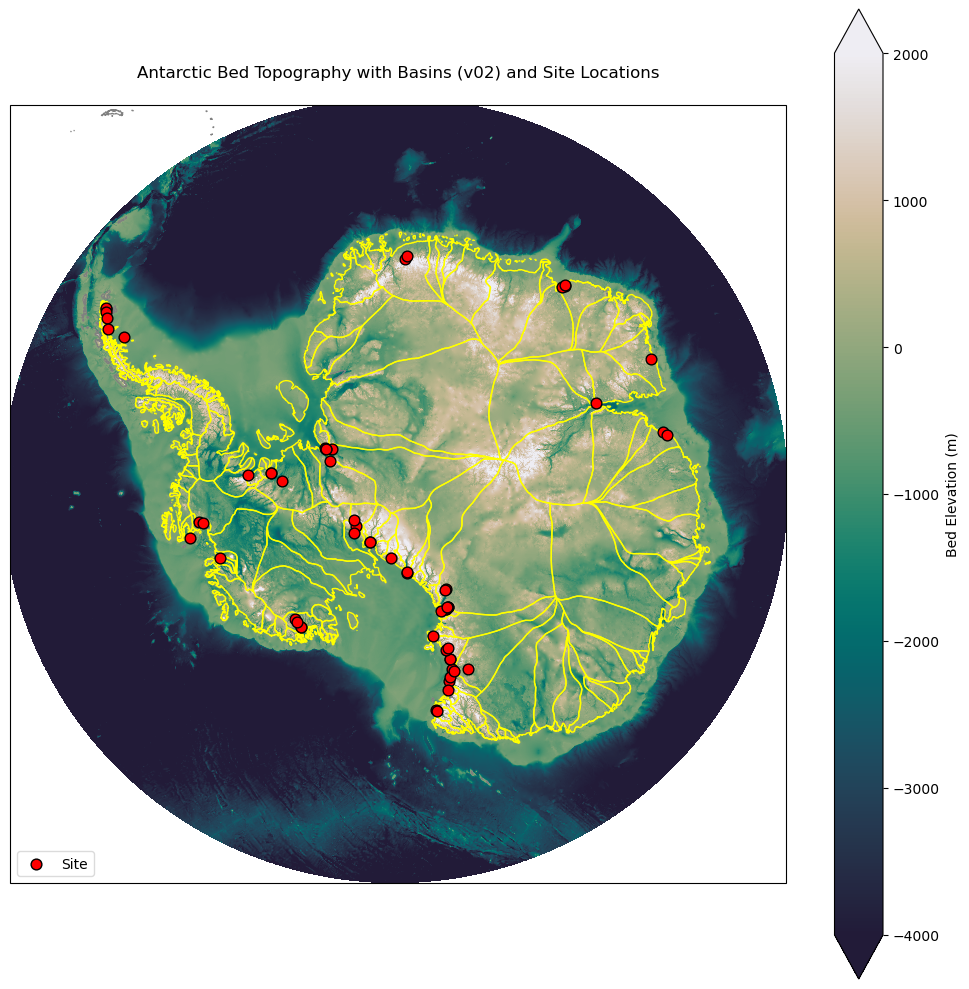

In [4]:
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import cmocean
import geopandas as gpd
from polartoolkit import fetch

# ── Step 0: If you haven't already, move aside the .prj so GeoPandas won’t auto-lookup EPSG:3031 ──
prj = "Basins_Antarctica_v02.prj"
if os.path.exists(prj):
    os.rename(prj, prj + ".bak")

# ── 1) Load & fix your Basins shapefile CRS ──
basins = gpd.read_file("Basins_Antarctica_v02.shp")
basins = basins.set_crs(
    "+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 "
    "+datum=WGS84 +units=m +no_defs",
    allow_override=True
)
# Note: we DO NOT reproject to epsg:4326; we’ll plot directly in polar-stereo coords.

# ── 2) Load the rest of your data ──
exfiltration_df = pd.read_csv("paleoexfiltrationperm13mean.csv")
unique_sites   = exfiltration_df[['Site','Latitude','Longitude']].drop_duplicates()
bed            = fetch.bedmap3(layer="bed")

# ── 3) Build the South-Polar map ──
proj = ccrs.SouthPolarStereo(central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":proj})

# a) Bed topography
bed.plot(
    ax=ax,
    transform=proj,             # bed is already in polar-stereo coords
    cmap=cmocean.cm.rain_r,
    vmin=-4000, vmax=2000,
    cbar_kwargs={'label':'Bed Elevation (m)'}
)

# b) Basins outlines (native polar-stereo)
basins.plot(
    ax=ax,
    transform=proj,
    facecolor='none',
    edgecolor='yellow',
    linewidth=1,
    zorder=5,
    label='Basins v02'
)

# c) Site markers (lon/lat → PlateCarree transform)
for i, row in unique_sites.iterrows():
    ax.scatter(
        row.Longitude, row.Latitude,
        color='red', s=60, marker='o',
        edgecolor='black',
        transform=ccrs.PlateCarree(),
        zorder=10,
        label='Site' if i==0 else ""
    )

# ── 4) Finish decorating ──
ax.coastlines(resolution='10m', linewidth=0.8, color='gray')
ax.set_extent([-180,180,-90,-60], crs=ccrs.PlateCarree())
ax.legend(loc='lower left', framealpha=0.7)
ax.set_title("Antarctic Bed Topography with Basins (v02) and Site Locations", pad=20)

plt.tight_layout()
# plt.savefig("Antarctic_Bed_Topo_Basins_Sites.pdf", dpi=300, bbox_inches='tight')
plt.show()


# Site Figure (Landsat Image)

grdimage [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage [WARNING]: e reset from 2800000 to 2800124.3212


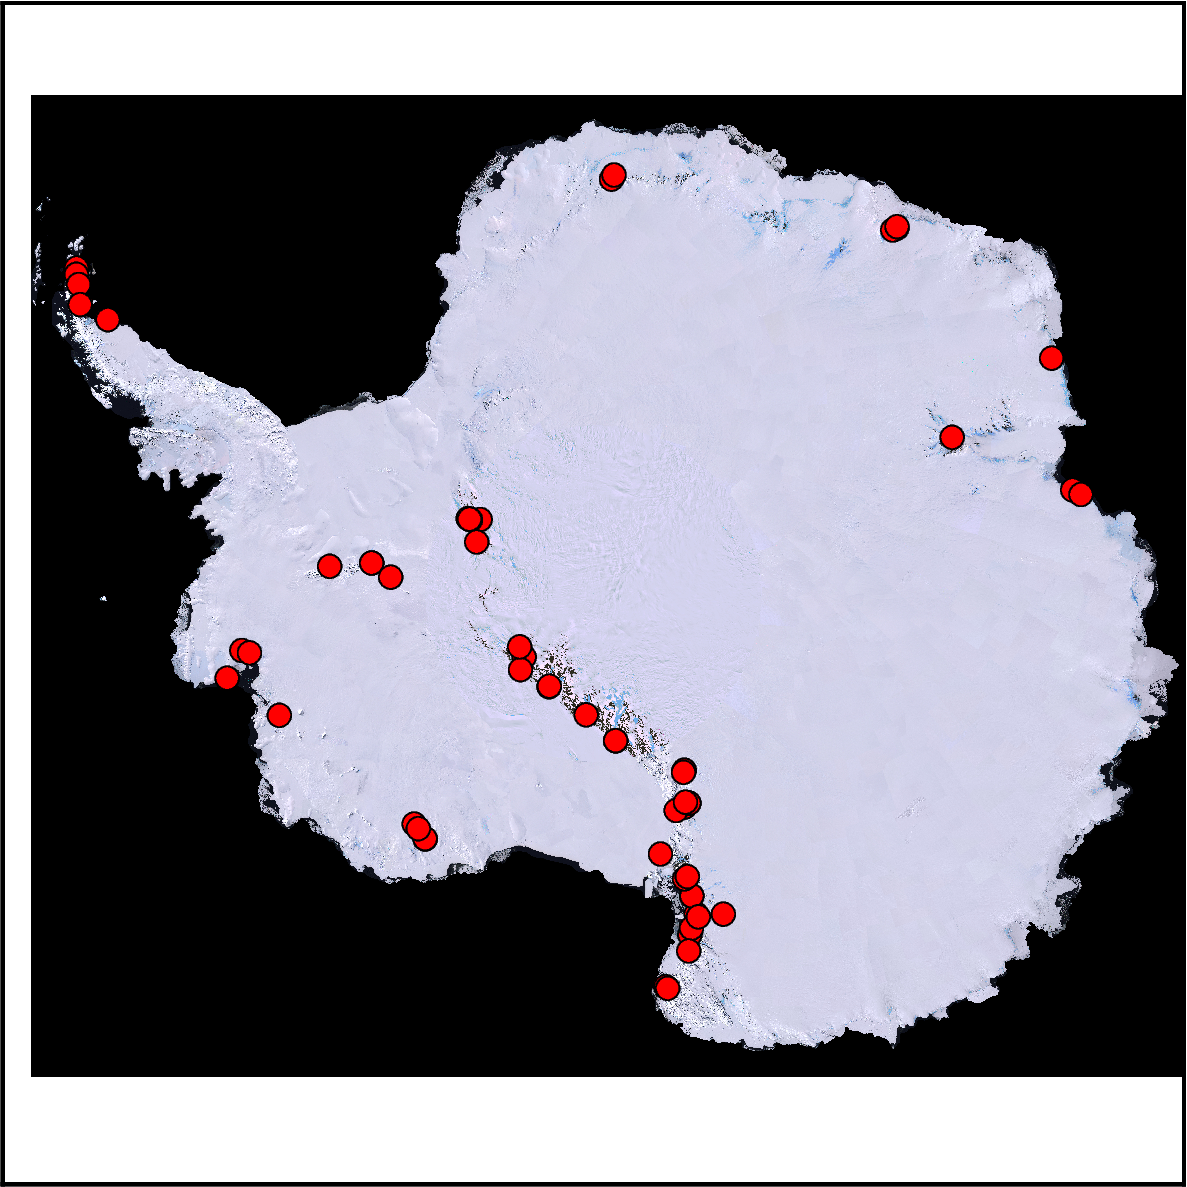

In [5]:
import os
import warnings
import pandas as pd
from pyproj import Transformer
from polartoolkit import fetch, maps

# ─────────────────────────────────────────────────────────
# (A) Suppress the benign grdimage warning (optional)
warnings.filterwarnings(
    "ignore", 
    message="grdimage \\[WARNING\\]: \\(e - x_min\\) must equal.*"
)

# ─────────────────────────────────────────────────────────
# (1) Southern hemisphere default
os.environ["POLARTOOLKIT_HEMISPHERE"] = "south"

# (2) Load your master sites CSV
df = pd.read_csv("paleoexfiltrationperm13mean.csv")
sites = df[['Longitude','Latitude']].drop_duplicates()

# (3) Project from EPSG:4326 → EPSG:3031 (Antarctic Stereographic)
tf = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
x_pts, y_pts = tf.transform(sites.Longitude.values, sites.Latitude.values)

# ─────────────────────────────────────────────────────────
# (4) Fetch and plot the LIMA basemap
_ = fetch.imagery()
fig = maps.basemap(
    imagery_basemap=True,
    hemisphere="south",
    #title="LIMA with All Exfiltration Sites",
    coast=False,
    coast_pen="0.6p,salmon",
    colorbar=False
)

# (5) Overlay all your points in projected metre‐space
fig.plot(
    x=x_pts,
    y=y_pts,
    style="c0.3c",          # 0.3 cm circles
    fill="red",
    pen="0.5p,black",
)

# (6) Render at high resolution
fig.show(dpi=200)


# Hydropotential Map (Full Continent) With Sites

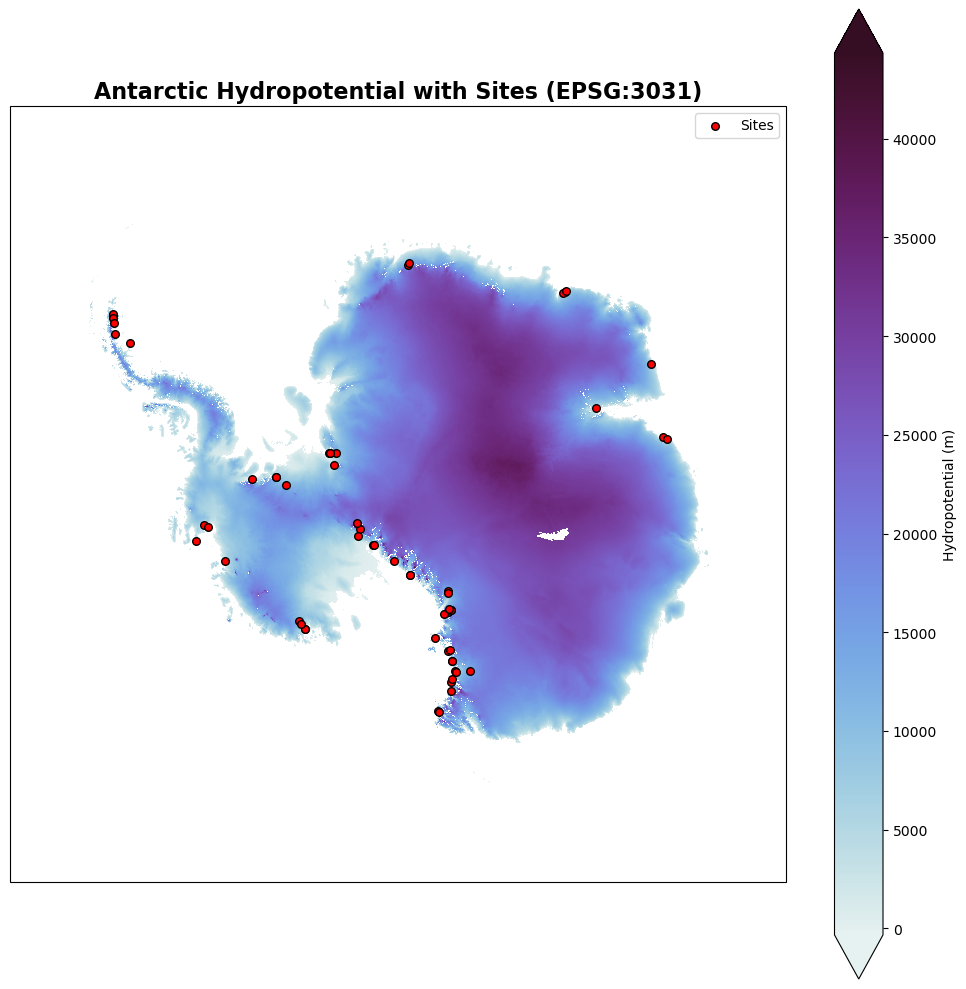

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import xarray as xr
import cmocean

# --- Load site data ---
exfiltration_df = pd.read_csv("paleoexfiltrationperm13mean.csv")
unique_sites = exfiltration_df[['Site', 'Latitude', 'Longitude']].drop_duplicates()

# --- Load hydropotential data (already in Polar Stereographic meters) ---
ds = xr.open_dataset("Antarctic_hydropotential.nc")
hydropotential = ds['hydropotential']


# --- Define target CRS matching EPSG:3031 ---
tgt_crs = ccrs.SouthPolarStereo(
    central_longitude=0, 
    true_scale_latitude=-71  # matches EPSG:3031
)

# --- Plot full Antarctica ---
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(1, 1, 1, projection=tgt_crs)

# Plot hydropotential grid (already projected)
hydropotential.plot(
    ax=ax,
    transform=tgt_crs,      # grid already in this projection
    cmap=cmocean.cm.dense,
    vmin=-334.2,
    vmax=44339.6,
    cbar_kwargs={'label': 'Hydropotential (m)'}
)

# Plot site locations (lat/lon → polar stereo on‐the‐fly)
ax.scatter(
    unique_sites["Longitude"], 
    unique_sites["Latitude"],
    color='red', 
    s=30, 
    edgecolor='black',
    transform=ccrs.PlateCarree(), 
    zorder=5,
    label="Sites"
)

# Add legend
ax.legend(loc="upper right", fontsize=10)

# Set full Antarctic extent (in meters for Polar Stereo grid)
ax.set_extent([-3333000, 3333000, -3333000, 3333000], crs=tgt_crs)

# Add title
ax.set_title("Antarctic Hydropotential with Sites (EPSG:3031)", fontsize=16, weight='bold')

# Save and show
plt.tight_layout()
# plt.savefig("antarctic_hydropotential_with_sites_final.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
# # Compute absolute min/max

# min_hp = hydropotential_coarse.min().item()
# max_hp = hydropotential_coarse.max().item()
# print(f"Hydropotential range: {min_hp:.1f} m to {max_hp:.1f} m")

In [8]:
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import xarray as xr
import geopandas as gpd
import cmocean

# --- Load site data ---
exfiltration_df = pd.read_csv("paleoexfiltrationperm13mean.csv")
unique_sites = exfiltration_df[['Site','Latitude','Longitude']].drop_duplicates()

# --- Load hydropotential ---
ds = xr.open_dataset("Antarctic_hydropotential.nc")
hydropotential = ds['hydropotential']

# --- Projection ---
polar_stereo = ccrs.Stereographic(
    central_latitude=-90, 
    central_longitude=0,
    true_scale_latitude=-71   # matches EPSG:3031
)


# East Antarctica 

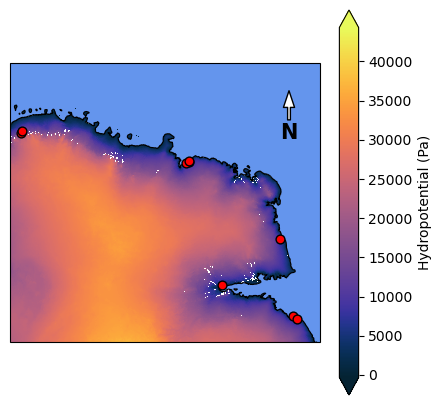

In [9]:
# --- Plot ---
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(1,1,1, projection=polar_stereo)

# 0) grey ocean under everything
ax.add_feature(cfeature.OCEAN.with_scale('10m'),
               facecolor='cornflowerblue', zorder=0)

# 1) hydropotential
hydropotential.plot(
    ax=ax,
    transform=polar_stereo,
    cmap=cmocean.cm.thermal,
    vmin=-334.2,
    vmax=44339.6,
    cbar_kwargs={'label':'Hydropotential (Pa)'}
)

# 2) Amery extent
ax.set_extent([0, 80, -75, -67], crs=ccrs.PlateCarree())

# 3) grounding line or fallback coastline
gl_shp = "bedmap2_grounding_line.shp"
if os.path.exists(gl_shp):
    gl = gpd.read_file(gl_shp).to_crs("EPSG:3031")
    gl.plot(
        ax=ax,
        transform=polar_stereo,
        facecolor='none',
        edgecolor='k',
        linewidth=1.0,
        zorder=3
    )
else:
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'),
                   edgecolor='k', linewidth=0.8, zorder=3)

# 4) sites
ax.scatter(
    unique_sites.Longitude,
    unique_sites.Latitude,
    transform=ccrs.PlateCarree(),
    color='red', edgecolor='black', s=40, zorder=4,
    # label="Sites"
)

# 5) north arrow (top right)
ax.annotate(
    'N',
    xy=(0.9, 0.9),        # arrow tip at top right
    xytext=(0.9, 0.75),   # text below the tip
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        facecolor='white',
        width=2,
        headwidth=8
    ),
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold'
)
plt.savefig("eastantarctica.png", dpi=700)

# Antarctic Peninsula 

In [ ]:
# --- Plot with portrait orientation ---
fig = plt.figure(figsize=(5, 5))
ax  = plt.subplot(1,1,1, projection=polar_stereo)

# 0) grey ocean under everything
ax.add_feature(cfeature.OCEAN.with_scale('10m'),
               facecolor='cornflowerblue', zorder=0)

# 1) hydropotential
hydropotential.plot(
    ax=ax,
    transform=polar_stereo,
    cmap=cmocean.cm.thermal,
    vmin=-334.2,
    vmax=44339.6,
    cbar_kwargs={'label':'Hydropotential (m)'}
)

# 2) Northern Transantarctic Mountains extent
ax.set_extent([-75, -50, -78, -63], crs=ccrs.PlateCarree())

# 3) overlay grounding‑line or coastlines
gl_shp = "bedmap2_grounding_line.shp"
if os.path.exists(gl_shp):
    gl = gpd.read_file(gl_shp).to_crs("EPSG:3031")
    gl.plot(ax=ax,
            transform=polar_stereo,
            facecolor='none',
            edgecolor='k',
            linewidth=1.0,
            zorder=3)
else:
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'),
                   edgecolor='k', linewidth=0.8, zorder=3)

# 4) (Optional) site locations
ax.scatter(unique_sites.Longitude,
           unique_sites.Latitude,
           transform=ccrs.PlateCarree(),
           color='red', edgecolor='black', s=40, zorder=4)

# 5) north arrow (top right)
ax.annotate(
    'N',
    xy=(0.9, 0.9),        # arrow tip at top right
    xytext=(0.9, 0.75),   # text below the tip
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        facecolor='white',
        width=2,
        headwidth=8
    ),
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold'
)

plt.savefig("antarcticpeninsula.png", dpi=700)

# Marie Byrd Land

In [ ]:
# --- Plot ---
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(1,1,1, projection=polar_stereo)

# 0) grey ocean under everything
ax.add_feature(cfeature.OCEAN.with_scale('10m'),
               facecolor='cornflowerblue', zorder=0)

# 1) plot the coarse hydropotential
hydropotential.plot(
    ax=ax,
    transform=polar_stereo,
    cmap=cmocean.cm.thermal,
    vmin=-334.2,
    vmax=44339.6,
    cbar_kwargs={'label':'Hydropotential (m)'}
)

# 2) Marie Byrd Land embayment view
ax.set_extent([-145, -120, -84, -74], crs=ccrs.PlateCarree())

# 3) overlay grounding‑line or fallback coastlines
gl_shp = "bedmap2_grounding_line.shp"
if os.path.exists(gl_shp):
    gl = gpd.read_file(gl_shp).to_crs("EPSG:3031")
    gl.plot(
        ax=ax,
        transform=polar_stereo,
        facecolor='none',
        edgecolor='k',
        linewidth=1.0,
        zorder=3
    )
else:
    ax.add_feature(
        cfeature.COASTLINE.with_scale('10m'),
        edgecolor='k', linewidth=0.8, zorder=3
    )

# 4) plot the site locations
ax.scatter(
    unique_sites.Longitude, unique_sites.Latitude,
    transform=ccrs.PlateCarree(),
    color='red', edgecolor='black', s=50, zorder=4,
    label='Sites'
)

# 5) north arrow (top right)
ax.annotate(
    'N',
    xy=(0.9, 0.9),        # arrow tip at top right
    xytext=(0.9, 0.75),   # text below the tip
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        facecolor='white',
        width=2,
        headwidth=8
    ),
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold'
)


plt.savefig("mariebyrdland.png", dpi=700)

# Weddell Sea

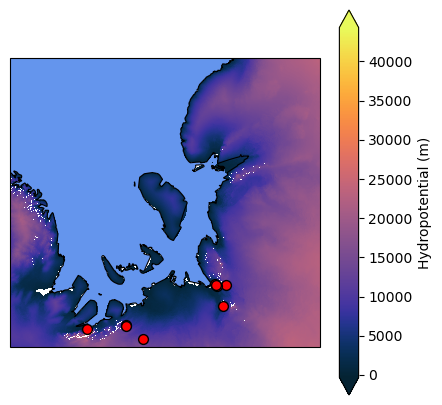

In [30]:
# --- Plot ---
fig = plt.figure(figsize=(5, 5))
ax = plt.subplot(1, 1, 1, projection=polar_stereo)

# 0) grey ocean under everything
ax.add_feature(
    cfeature.OCEAN.with_scale("10m"),
    facecolor="cornflowerblue",
    zorder=0
)

# 1) coarse hydropotential
hydropotential.plot(
    ax=ax,
    transform=polar_stereo,
    cmap=cmocean.cm.thermal,
    vmin=-334.2,
    vmax=44339.6,
    cbar_kwargs={"label": "Hydropotential (m)"}
)

# 2) Zoom into the Weddell Sea region
weddell_extent = [-70, -30, -89, -74]
ax.set_extent(weddell_extent, crs=ccrs.PlateCarree())

# 3) overlay grounding‐line or coastlines
gl_shp = "bedmap2_grounding_line.shp"
if os.path.exists(gl_shp):
    gl = gpd.read_file(gl_shp).to_crs("EPSG:3031")
    gl.plot(
        ax=ax,
        transform=polar_stereo,
        facecolor="none",
        edgecolor="k",
        linewidth=1.0,
        zorder=3
    )
else:
    ax.add_feature(
        cfeature.COASTLINE.with_scale("10m"),
        edgecolor="k",
        linewidth=0.8,
        zorder=3
    )

# 4) plot site locations
ax.scatter(
    unique_sites.Longitude,
    unique_sites.Latitude,
    transform=ccrs.PlateCarree(),
    color="red",
    edgecolor="black",
    s=50,
    zorder=4,
    label="Sites"
)

# # 5) north arrow (top right)
# ax.annotate(
#     'N',
#     xy=(0.9, 0.9),        # arrow tip at top right
#     xytext=(0.9, 0.75),   # text below the tip
#     xycoords='axes fraction',
#     textcoords='axes fraction',
#     arrowprops=dict(
#         facecolor='white',
#         width=2,
#         headwidth=8
#     ),
#     ha='center',
#     va='center',
#     fontsize=15,
#     fontweight='bold'
# )

plt.savefig("weddellsea.png", dpi=700)

# Transantarctic Mountains 

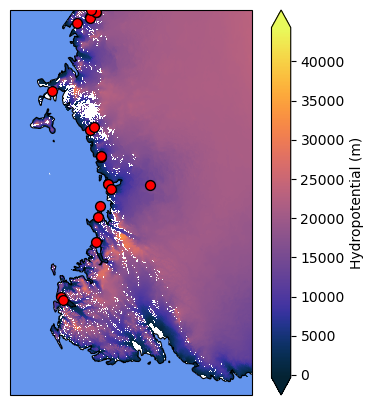

In [12]:
# --- Projection ---
fig = plt.figure(figsize=(5, 5))
ax = plt.subplot(1, 1, 1, projection=polar_stereo)

# 0) grey ocean underlay
ax.add_feature(
    cfeature.OCEAN.with_scale('10m'),
    facecolor='cornflowerblue',
    zorder=0
)

# 1) plot the coarse hydropotential
hydropotential.plot(
    ax=ax,
    transform=polar_stereo,
    cmap=cmocean.cm.thermal,
    vmin=-334.2,
    vmax=44339.6,
    cbar_kwargs={'label': 'Hydropotential (m)'}
)

# 2) Northern Transantarctic Mountains extent
ax.set_extent([155, 170, -70, -80], crs=ccrs.PlateCarree())

# 3) overlay grounding‑line or coastlines
gl_shp = "bedmap2_grounding_line.shp"
if os.path.exists(gl_shp):
    gl = gpd.read_file(gl_shp).to_crs("EPSG:3031")
    gl.plot(
        ax=ax,
        transform=polar_stereo,
        facecolor='none',
        edgecolor='k',
        linewidth=1.0,
        zorder=3
    )
else:
    ax.add_feature(
        cfeature.COASTLINE.with_scale('10m'),
        edgecolor='k',
        linewidth=0.8,
        zorder=3
    )

# 4) plot your site locations
ax.scatter(
    unique_sites.Longitude,
    unique_sites.Latitude,
    transform=ccrs.PlateCarree(),
    color="red",
    edgecolor="black",
    s=50,
    zorder=4,
    label="Sites"
)

# # 5) north arrow (top right)
# ax.annotate(
#     'N',
#     xy=(0.9, 0.9),        # arrow tip
#     xytext=(0.9, 0.75),   # text position
#     xycoords='axes fraction',
#     textcoords='axes fraction',
#     arrowprops=dict(
#         facecolor='white',
#         width=2,
#         headwidth=8
#     ),
#     ha='center',
#     va='center',
#     fontsize=12,
#     fontweight='bold'
# )

plt.savefig("transantarcticmountains.png", dpi=700)

# Amundsen Sea

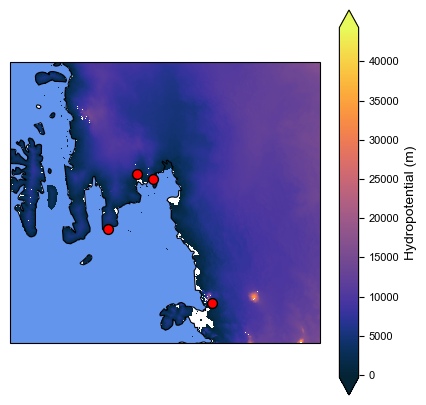

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import geopandas as gpd
import os

# --- Plot ---
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(1,1,1, projection=polar_stereo)

# 0) grey ocean underlay
ax.add_feature(
    cfeature.OCEAN.with_scale('10m'),
    facecolor='cornflowerblue',
    zorder=0
)

# 1) plot the coarse hydropotential and capture the colorbar
hydropot_plot = hydropotential.plot(
    ax=ax,
    transform=polar_stereo,
    cmap=cmocean.cm.thermal,
    vmin=-334.2,
    vmax=44339.6,
    cbar_kwargs={'label': 'Hydropotential (m)'}
)

# Set Arial font for colorbar label and ticks
hydropot_plot.colorbar.ax.set_ylabel('Hydropotential (m)', fontname='Arial', fontsize=10)
for label in hydropot_plot.colorbar.ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(8)

# 2) customized Amundsen Sea embayment view
ax.set_extent([-110, -90, -78, -72], crs=ccrs.PlateCarree())

# 3) overlay grounding‑line or coastlines
gl_shp = "bedmap2_grounding_line.shp"
if os.path.exists(gl_shp):
    gl = gpd.read_file(gl_shp).to_crs("EPSG:3031")
    gl.plot(
        ax=ax,
        transform=polar_stereo,
        facecolor='none',
        edgecolor='k',
        linewidth=1.0,
        zorder=3
    )
else:
    ax.add_feature(
        cfeature.COASTLINE.with_scale('10m'),
        edgecolor='k', linewidth=0.8, zorder=3
    )

# 4) plot the site locations
ax.scatter(
    unique_sites.Longitude, unique_sites.Latitude,
    transform=ccrs.PlateCarree(),
    color='red', edgecolor='black', s=50, zorder=4,
    label='Sites'
)

# # 5) north arrow (top right)
# ax.annotate(
#     'N',
#     xy=(0.9, 0.9),
#     xytext=(0.9, 0.75),
#     xycoords='axes fraction',
#     textcoords='axes fraction',
#     arrowprops=dict(
#         facecolor='white',
#         width=2,
#         headwidth=8
#     ),
#     ha='center',
#     va='center',
#     fontsize=12,
#     fontweight='bold',
#     fontname='Arial'
# )

plt.savefig("amundsensea.png", dpi=700)


# Plot Mean Paleoexfiltration Values on Map 

In [25]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import numpy as np
# import pandas as pd
# import cmocean
# from matplotlib import colors
# import rasterio
# from polartoolkit import fetch

# # --- 0) Define your custom SymLog norm ---
# class CustomSymLogNorm(colors.SymLogNorm):
#     def __init__(self,
#                  linthresh=1e-8,
#                  linscale=0.03,
#                  vmin=1e-8,
#                  vmax=1e-3):
#         super().__init__(
#             linthresh=linthresh,
#             linscale=linscale,
#             vmin=vmin,
#             vmax=vmax
#         )

# norm = CustomSymLogNorm(
#     linthresh=1e-8,
#     linscale=0.03,
#     vmin=1e-8,
#     vmax=1e-3
# )
# cmap = cmocean.cm.matter.reversed()

# # --- 1) Load your site data ---
# exfiltration_df = pd.read_csv("paleoexfiltrationperm11mean.csv")
# sites = exfiltration_df[['Site','Latitude','Longitude','Exfiltration (mm/yr)']].drop_duplicates()

# # --- 2) Load LIMA Landsat basemap ---
# lima_tif = fetch.imagery()  # downloads the LIMA mosaic
# with rasterio.open(lima_tif) as src:
#     # read RGB bands
#     rgb = src.read([1, 2, 3])
#     left, bottom, right, top = src.bounds

# # --- 3) Start the figure & polar stereographic axes ---
# fig = plt.figure(figsize=(10,10))
# ax  = plt.subplot(1,1,1, projection=ccrs.SouthPolarStereo())

# # --- 4) Plot the Landsat mosaic as the basemap ---
# ax.imshow(
#     np.transpose(rgb, (1,2,0)) / 255.0,  # scale 0–255 to [0–1]
#     origin='upper',
#     extent=(left, right, bottom, top),
#     transform=ccrs.SouthPolarStereo(),
#     zorder=0
# )

# # --- 5) Coastlines & extent ---
# ax.coastlines(resolution='10m', linewidth=0.8)
# ax.set_extent([-180,180,-90,-60], crs=ccrs.PlateCarree())

# # --- 6) Scatter your sites with color & size ~ rate ---
# sc = ax.scatter(
#     sites["Longitude"],
#     sites["Latitude"],
#     c=sites["Exfiltration (mm/yr)"],
#     cmap=cmap,
#     norm=norm,
#     s=200 + (sites["Exfiltration (mm/yr)"] / 100) * 400,
#     edgecolor='black',
#     linewidth=0.5,
#     transform=ccrs.PlateCarree(),
#     zorder=10
# )

# # --- 7) Colorbar for exfiltration rate ---
# cax = fig.add_axes([0.93, 0.2, 0.015, 0.6])
# cb  = plt.colorbar(sc, cax=cax, orientation='vertical')
# cb.set_label("Lower CI (2.5%) Exfiltration Rate (mm yr⁻¹)", fontsize=12)
# cb.ax.tick_params(labelsize=10)

# plt.savefig("paleoexfiltrationperm11.png", dpi=300, bbox_inches='tight')

In [38]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import numpy as np
# import pandas as pd
# import cmocean
# from matplotlib import colors

# # --- 0) Define your custom SymLog norm ---
# class CustomSymLogNorm(colors.SymLogNorm):
#     def __init__(self,
#                  linthresh=1e-7,
#                  linscale=0.03,
#                  vmin=1e-7,
#                  vmax=1e-4):
#         super().__init__(
#             linthresh=linthresh,
#             linscale=linscale,
#             vmin=vmin,
#             vmax=vmax
#         )

# norm = CustomSymLogNorm(
#     linthresh=1e-7,
#     linscale=0.03,
#     vmin=1e-7,
#     vmax=1e-4
# )
# cmap = cmocean.cm.matter.reversed()

# # --- 1) Load your site data ---
# exfiltration_df = pd.read_csv("full_exfiltration_timeseries_perm13_mean.csv")
# sites = exfiltration_df[['Site','Latitude','Longitude','Exfiltration (mm/yr)']].drop_duplicates()

# # --- 2) Load Bedmap3 topography ---
# bed = fetch.bedmap3(layer="bed")

# # --- 3) Start the figure & polar stereographic axes ---
# fig = plt.figure(figsize=(10,10))
# ax  = plt.subplot(1,1,1, projection=ccrs.SouthPolarStereo())

# # --- 4) Plot bed elevation as the basemap ---
# bed.plot(
#     ax=ax,
#     transform=ccrs.SouthPolarStereo(),
#     cmap=cmocean.cm.rain_r,
#     vmin=-4000,
#     vmax=2000,
#     # cbar_kwargs={'label': 'Bed Elevation (m)', 'shrink':0.5}
# )

# # --- 5) Coastlines & extent ---
# ax.coastlines(resolution='10m', linewidth=0.8)
# ax.set_extent([-180,180,-90,-60], crs=ccrs.PlateCarree())

# # --- 6) Scatter your sites with color & size ~ rate ---
# sc = ax.scatter(
#     sites["Longitude"],
#     sites["Latitude"],
#     c=sites["Exfiltration (mm/yr)"],
#     cmap=cmap,
#     norm=norm,
#     s=100 + (sites["Exfiltration (mm/yr)"] / 100) * 400,
#     edgecolor='black',
#     linewidth=0.5,
#     transform=ccrs.PlateCarree(),
#     zorder=10
# )

# # --- 7) Colorbar for exfiltration rate ---
# cax = fig.add_axes([0.93, 0.2, 0.015, 0.6])
# cb  = plt.colorbar(sc, cax=cax, orientation='vertical')
# cb.set_label("Mean Exfiltration Rate (mm yr⁻¹)", fontsize=12)
# cb.ax.tick_params(labelsize=10)

# # --- 8) Title & save ---
# plt.title("Antarctic Bed Topography with Mean Exfiltration Rates", fontsize=14)
# plt.tight_layout()
# # plt.savefig("Antarctic_Bedmap3_with_Exfiltration.pdf", dpi=300, bbox_inches="tight")
# plt.show()


# Make GIF of results in 500 year steps

In [2]:
# #!/usr/bin/env python3
# """
# Generate animated frames of lower-CI exfiltration rates over Antarctica,
# with the simple scatter-based vertical colorbar.
# """

# import os
# import gc
# import warnings

# import pandas as pd
# import numpy as np
# import rasterio
# import cmocean
# import matplotlib
# matplotlib.use("Agg")  # no GUI/backend
# import matplotlib.pyplot as plt
# from matplotlib import colors
# import cartopy.crs as ccrs
# from rasterio.transform import array_bounds
# from polartoolkit import fetch

# # -----------------------------------------------------------------------------
# # Suppress harmless GMT warnings
# warnings.filterwarnings(
#     "ignore",
#     message=r"grdimage \[WARNING\]: \(e - x_min\) must equal.*"
# )

# # -----------------------------------------------------------------------------
# # 1) Custom SymLog normalization + reversed colormap
# class CustomSymLogNorm(colors.SymLogNorm):
#     def __init__(self,
#                  linthresh: float = 1e-8,
#                  linscale: float = 0.03,
#                  vmin: float = 1e-8,
#                  vmax: float = 1e-3):
#         super().__init__(
#             linthresh=linthresh,
#             linscale=linscale,
#             vmin=vmin,
#             vmax=vmax
#         )

# norm = CustomSymLogNorm()
# cmap = cmocean.cm.matter.reversed()

# # -----------------------------------------------------------------------------
# # 2) Read data and define sample ages
# exfil_df = pd.read_csv("paleoexfiltrationperm11mean.csv")
# sampling_ages = list(range(20_000, 0, -500))

# # -----------------------------------------------------------------------------
# # 3) Load & downsample LIMA basemap once
# lima_path = fetch.imagery()
# with rasterio.open(lima_path) as src:
#     scale = 0.1
#     out_shape = (3, int(src.height * scale), int(src.width * scale))
#     rgb = src.read([1, 2, 3], out_shape=out_shape) / 255.0
#     transform = src.transform * src.transform.scale(
#         src.width  / out_shape[2],
#         src.height / out_shape[1]
#     )
# left, bottom, right, top = array_bounds(out_shape[1], out_shape[2], transform)

# # -----------------------------------------------------------------------------
# # 4) Loop over each age, plot, and save
# for age in sampling_ages:
#     df_age = exfil_df[exfil_df["Age"] == age]
#     if df_age.empty:
#         continue

#     fig = plt.figure(figsize=(10, 10))
#     ax = plt.axes(projection=ccrs.SouthPolarStereo())

#     # Plot basemap
#     ax.imshow(
#         np.transpose(rgb, (1, 2, 0)),
#         origin="upper",
#         extent=(left, right, bottom, top),
#         transform=ccrs.SouthPolarStereo(),
#         zorder=0
#     )
#     ax.coastlines(resolution="110m", linewidth=0.8)
#     ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

#     # Scatter exfiltration rates
#     sc = ax.scatter(
#         df_age["Longitude"], df_age["Latitude"],
#         c=df_age["Exfiltration (mm/yr)"],
#         cmap=cmap,
#         norm=norm,
#         s=200 + (df_age["Exfiltration (mm/yr)"] / 100) * 400,
#         edgecolor="black",
#         linewidth=0.5,
#         transform=ccrs.PlateCarree(),
#         zorder=10
#     )

#     # --- 7) Colorbar for exfiltration rate (simple) ---
#     cax = fig.add_axes([0.93, 0.2, 0.015, 0.6])
#     cb  = plt.colorbar(sc, cax=cax, orientation='vertical')
#     cb.set_label("Mean Exfiltration Rate (mm yr⁻¹)", fontsize=12)
#     cb.ax.tick_params(labelsize=10)

#     # Save frame
#     out_fname = f"frame_{age:05d}.png"  # zero-pad for correct ordering
#     fig.savefig(out_fname, dpi=150, bbox_inches="tight")
#     plt.close(fig)
#     gc.collect()



In [3]:
# from PIL import Image, ImageDraw, ImageFont
# import os
# import glob
# import re
# import matplotlib.font_manager as fm

# # Define regex to catch filenames with an age number,
# # e.g. frame_2000.png or MeanExfiltration_2000.jpeg
# pattern = re.compile(
#     r'(?:(?:frame_|MeanExfiltration_))(\d+)\.(png|jpe?g)$',
#     re.IGNORECASE
# )

# # Find all matching files in cwd
# matched = []
# for filepath in glob.glob("*.*"):
#     fname = os.path.basename(filepath)
#     m = pattern.match(fname)
#     if m:
#         age = int(m.group(1))
#         matched.append((age, filepath))

# if not matched:
#     print(
#         "No matching frames were found in the directory. "
#         "Ensure files are named like 'frame_<age>.png' or 'MeanExfiltration_<age>.jpeg'."
#     )
# else:
#     # Sort by descending age so the GIF goes from oldest to youngest
#     matched.sort(key=lambda x: x[0], reverse=True)
#     ages, files = zip(*matched)
#     print("Found and will annotate frames in order:", ages)

#     # Attempt to load a real TrueType font; fall back to default otherwise
#     try:
#         font_path = fm.findfont("Arial")
#         font = ImageFont.truetype(font_path, size=30)
#     except Exception:
#         font = ImageFont.load_default()

#     annotated_frames = []
#     for age, fn in matched:
#         im = Image.open(fn).convert("RGB")
#         draw = ImageDraw.Draw(im)

#         text = f"{age:,} years ago"
#         x, y = 50, 50

#         # Draw text with a 2px black stroke and white fill
#         draw.text(
#             (x, y),
#             text,
#             font=font,
#             fill="black",
#         )

#         annotated_frames.append(im)

#     # Save out as an animated GIF
#     out_gif = "paleoexfiltrationmeanperm11.gif"
#     annotated_frames[0].save(
#         out_gif,
#         save_all=True,
#         append_images=annotated_frames[1:],
#         duration=500,  # milliseconds per frame
#         loop=0
#     )
#     print(f"✅ Annotated GIF saved as '{out_gif}'")


Found and will annotate frames in order: (20000, 19500, 19000, 18500, 18000, 17500, 17000, 16500, 16000, 15500, 15000, 14500, 14000, 13500, 13000, 12500, 12000, 11500, 11000, 10500, 10000, 9500, 9000, 8500, 8000, 7500, 7000, 6500, 6000, 5500, 5000, 4500, 4000, 3500, 3000, 2500, 2000, 1500, 1000, 500)
✅ Annotated GIF saved as 'paleoexfiltrationmeanperm11.gif'
